
---

## Triple Barrier Method — концепция

Triple Barrier Method — метод разметки финансовых временных рядов из главы 3 AFML. Идея простая: для каждого наблюдения мы открываем воображаемую позицию и смотрим что произойдёт раньше — цена вырастет до take profit, упадёт до stop loss, или истечёт время удержания.

Три барьера:

```
+pt  ────────────────────────  верхний барьер (take profit) → метка +1
      ╲
       ╲   цена идёт вниз
        ╲
-sl  ────────────────────────  нижний барьер (stop loss)    → метка -1

t+T  ────────────────────────  вертикальный барьер (таймаут) → метка 0
```

Какой барьер сработал первым — такую метку получает наблюдение:

- `+1` — цена достигла верхнего барьера раньше нижнего и таймаута
- `−1` — цена достигла нижнего барьера раньше верхнего и таймаута
- `0` — ни один горизонтальный барьер не сработал за отведённое время

Это принципиально отличается от наивной разметки через знак доходности через N баров. Там метка зависит только от одной точки в будущем — что происходило между входом и выходом неизвестно. Triple barrier смотрит на весь путь цены и отражает реальный торговый результат: позиция закрывается либо по прибыли, либо по убытку, либо по времени.

## Dynamic Thresholds — вычисление дневной волатильности

### Зачем это нужно

Triple Barrier Method требует задать ширину горизонтальных барьеров — уровни take profit и stop loss. Самый простой вариант — фиксированный порог, например ±2%. Но он ломается на разных рыночных режимах:

```
Спокойный рынок:   vol = 0.1%/день  →  барьер ±2% никогда не срабатывает
Волатильный рынок: vol = 5%/день    →  барьер ±2% срабатывает на случайном шуме
```

В первом случае почти все наблюдения получат метку 0 (таймаут). Во втором — метки будут случайными. Модель не сможет выучить ничего полезного из таких меток.

Решение — адаптировать ширину барьеров к текущей волатильности. Когда рынок спокойный — барьеры узкие. Когда волатильный — широкие. Это делает метки статистически однородными на всём периоде 2020–2026.

---

### Как считается волатильность — `getDailyVol`

Функция `getDailyVol` из AFML (глава 3) вычисляет дневную волатильность для каждого бара:

```python
def getDailyVol(close, span0=100):
    df0 = close.index.searchsorted(close.index - pd.Timedelta(days=1))
    df0 = df0[df0 > 0]
    df0 = pd.Series(
        close.index[df0 - 1],
        index=close.index[close.shape[0] - df0.shape[0]:]
    )
    df0 = close.loc[df0.index] / close.loc[df0.values].values - 1
    df0 = df0.ewm(span=span0).std()
    return df0
```

Что происходит внутри — три шага:

**Шаг 1.** Для каждого бара находим бар примерно сутки назад. Не фиксированное количество баров назад, а именно по времени — потому что dollar bars неравномерные: в активные периоды их много, в тихие — мало.

**Шаг 2.** Считаем доходность от того бара до текущего — это однодневная доходность в точке наблюдения.

**Шаг 3.** Сглаживаем через EWMA с `span=100`. Каждый новый день весит ~2%, предыдущие 100 дней формируют ~86% оценки. Результат — медленно меняющаяся оценка текущего уровня дневного риска.

---

### Как волатильность становится барьером

```python
vol = getDailyVol(close, span0=100)

pt = +multiplier * vol   # верхний барьер — take profit
sl = -multiplier * vol   # нижний барьер — stop loss
```

`multiplier` — единственный параметр который мы выбираем. Он задаёт сколько сигм от текущей волатильности составляет барьер:

```
multiplier = 1  →  барьер = ±1σ  →  срабатывает часто, много меток, больше шума
multiplier = 2  →  барьер = ±2σ  →  умеренная частота, баланс сигнал/шум
multiplier = 3  →  барьер = ±3σ  →  срабатывает редко, мало меток, только сильные движения
```

---

### Вертикальный барьер — таймаут позиции

Кроме горизонтальных барьеров, triple barrier включает вертикальный — максимальное время удержания позиции. Если за это время ни один горизонтальный барьер не сработал — позиция закрывается принудительно с меткой 0.

Тестируем три горизонта:

| Вариант | Горизонт | Примерно баров (~30m dollar bars) |
|---------|----------|-----------------------------------|
| Short   | 1 день   | ~48 баров |
| Medium  | 5 дней   | ~240 баров |
| Long    | 10 дней  | ~480 баров |

Короткий горизонт — больше меток, но модель видит только краткосрочные движения. Длинный — меньше меток, но захватывает более устойчивые тренды.

---

### Сетка экспериментов

Перебираем все комбинации:

```
multiplier ∈ {1, 2, 3}  ×  horizon ∈ {1d, 5d, 10d}  =  9 конфигураций
```

Для каждой смотрим:

- распределение меток: доля `{−1, 0, +1}`
- баланс классов — насколько классы близки к равномерному распределению
- итоговое количество меток после фильтра `minRet`

Цель — найти конфигурацию где классы достаточно сбалансированы и меток хватает для обучения модели.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time


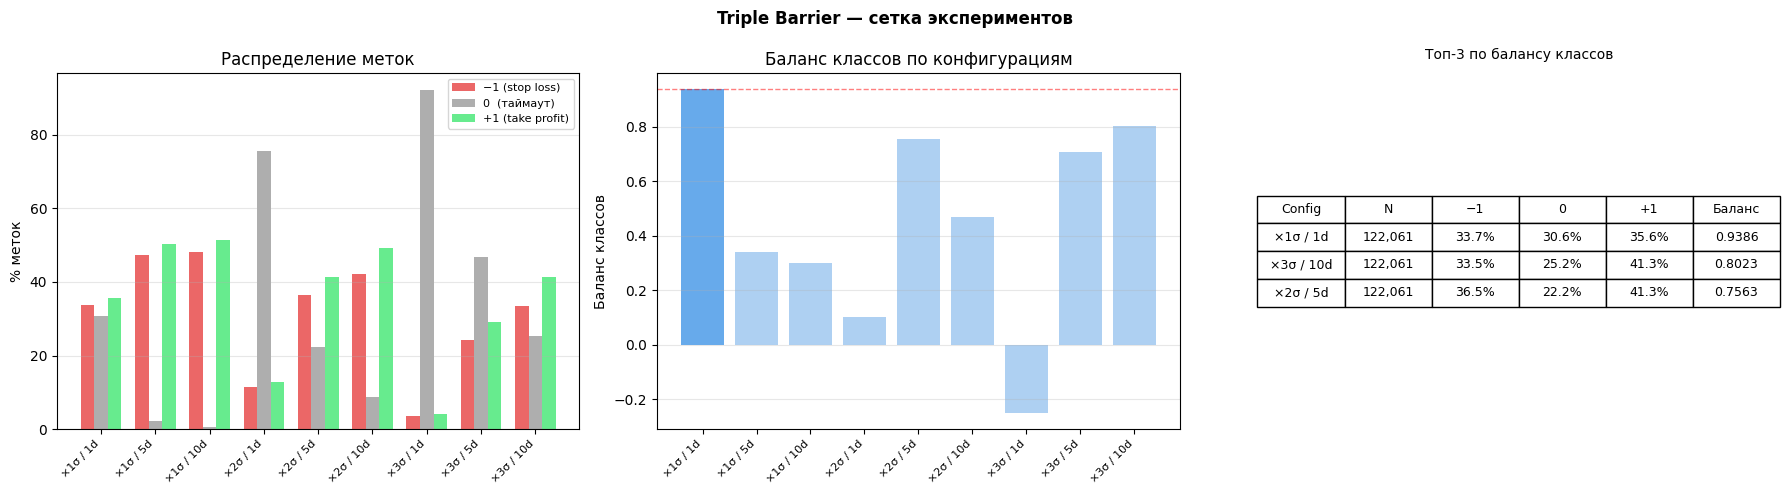

In [2]:

BARS_DIR = Path("data/bars")

df = pd.read_parquet(BARS_DIR / "dollar_bars_db_30m.parquet")
df["dt"] = pd.to_datetime(df["dt"])
df = df.set_index("dt").sort_index()
df = df[~df.index.duplicated(keep="first")]
close = df["close"]


def getDailyVol(close, span0=100):
    idx_arr    = close.index.searchsorted(close.index - pd.Timedelta(days=1))
    idx_arr    = idx_arr[idx_arr > 0]
    close_curr = close.iloc[close.shape[0] - idx_arr.shape[0]:]
    close_prev = close.iloc[idx_arr - 1]
    daily_ret  = close_curr.values / close_prev.values - 1
    df0        = pd.Series(daily_ret, index=close_curr.index)
    return df0.ewm(span=span0).std()


vol = getDailyVol(close, span0=100).dropna()
vol = vol[~vol.index.duplicated(keep="first")]


def triple_barrier_vectorized(close_arr, vol_arr, mult, h_bars):
    n      = len(close_arr)
    labels = np.zeros(n, dtype=np.int8)
    t1_idx = np.minimum(np.arange(n) + h_bars, n - 1)

    for i in range(n):
        if i + 1 >= n:
            break

        t1   = t1_idx[i]
        p0   = close_arr[i]
        v    = vol_arr[i]
        pt   =  mult * v
        sl   = -mult * v
        path = close_arr[i+1: t1+1] / p0 - 1

        if len(path) == 0:
            continue

        pt_hit = np.argmax(path >= pt) if np.any(path >= pt) else -1
        sl_hit = np.argmax(path <= sl) if np.any(path <= sl) else -1

        if pt_hit == -1 and sl_hit == -1:
            labels[i] = 0
        elif sl_hit == -1:
            labels[i] = 1
        elif pt_hit == -1:
            labels[i] = -1
        else:
            labels[i] = 1 if pt_hit <= sl_hit else -1

    return labels


common_idx    = close.index.intersection(vol.index)
close_aligned = close.loc[common_idx]
vol_aligned   = vol.loc[common_idx]
close_arr     = close_aligned.values.astype(np.float64)
vol_arr       = vol_aligned.values.astype(np.float64)

multipliers = [1, 2, 3]
horizons    = [1, 5, 10]
results     = {}

for mult in multipliers:
    for h_days in horizons:
        config = f"×{mult}σ / {h_days}d"
        h_bars = h_days * 48
        labels = triple_barrier_vectorized(close_arr, vol_arr, mult, h_bars)

        n      = len(labels)
        n_neg  = (labels == -1).sum()
        n_zero = (labels ==  0).sum()
        n_pos  = (labels ==  1).sum()
        counts = np.array([n_neg, n_zero, n_pos])
        balance = 1 - counts.std() / counts.mean() if counts.mean() > 0 else 0

        results[config] = {"labels": labels, "n": n, "n_neg": n_neg,
                           "n_zero": n_zero, "n_pos": n_pos,
                           "balance": balance, "mult": mult, "h_days": h_days}


for config, res in results.items():
    mult   = res["mult"]
    h_days = res["h_days"]
    h_bars = h_days * 48
    labels = res["labels"]
    n      = len(common_idx)
    t1_pos = np.minimum(np.arange(n) + h_bars, n - 1)

    records = []
    for i, t0 in enumerate(common_idx):
        label = int(labels[i])
        p0    = close_arr[i]
        v     = vol_arr[i]

        if label == 0:
            t_touch = common_idx[t1_pos[i]]
        else:
            pt   = mult * v if label == 1 else -mult * v
            path = close_arr[i+1: t1_pos[i]+1] / p0 - 1
            hits = np.where(path >= pt)[0] if label == 1 else np.where(path <= pt)[0]
            touch_pos = i + 1 + hits[0] if len(hits) > 0 else t1_pos[i]
            t_touch   = common_idx[min(touch_pos, n-1)]

        records.append({"t0": t0, "t1": t_touch, "trgt": v,
                        "ret": close.loc[t_touch] / p0 - 1,
                        "bin": label, "mult": mult, "h_days": h_days})

    df_lab = pd.DataFrame(records).set_index("t0")
    df_lab.to_parquet(BARS_DIR / f"labels_tb_mult{mult}_h{h_days}d.parquet",
                      compression="snappy")


configs  = list(results.keys())
n_neg_p  = [results[c]["n_neg"]  / results[c]["n"] * 100 for c in configs]
n_zero_p = [results[c]["n_zero"] / results[c]["n"] * 100 for c in configs]
n_pos_p  = [results[c]["n_pos"]  / results[c]["n"] * 100 for c in configs]
balances = [results[c]["balance"] for c in configs]

sorted_by_balance = sorted(results.items(), key=lambda x: x[1]["balance"], reverse=True)

top3_rows = [[c,
              f"{r['n']:,}",
              f"{r['n_neg']/r['n']*100:.1f}%",
              f"{r['n_zero']/r['n']*100:.1f}%",
              f"{r['n_pos']/r['n']*100:.1f}%",
              f"{r['balance']:.4f}"]
             for c, r in sorted_by_balance[:3]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Triple Barrier — сетка экспериментов", fontsize=12, fontweight="bold")

x    = np.arange(len(configs))
w    = 0.25
ax   = axes[0]
ax.bar(x - w, n_neg_p,  w, label="−1 (stop loss)",  color="#E84C4C", alpha=0.85)
ax.bar(x,     n_zero_p, w, label="0  (таймаут)",    color="#A0A0A0", alpha=0.85)
ax.bar(x + w, n_pos_p,  w, label="+1 (take profit)", color="#4CE87A", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(configs, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("% меток")
ax.set_title("Распределение меток")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")

axes[1].bar(configs, balances,
            color=["#4C9BE8" if b == max(balances) else "#A0C8F0" for b in balances],
            alpha=0.85)
axes[1].set_xticks(range(len(configs)))
axes[1].set_xticklabels(configs, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Баланс классов")
axes[1].set_title("Баланс классов по конфигурациям")
axes[1].axhline(max(balances), color="red", linewidth=1, linestyle="--", alpha=0.5)
axes[1].grid(alpha=0.3, axis="y")

axes[2].axis("off")
tbl = axes[2].table(
    cellText=top3_rows,
    colLabels=["Config", "N", "−1", "0", "+1", "Баланс"],
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.8)
axes[2].set_title("Топ-3 по балансу классов", fontsize=10, pad=10)

plt.tight_layout()
plt.show()


## Triple Barrier Labeling — анализ результатов

### Сетка экспериментов

| Config | N | −1 | 0 | +1 | Баланс |
|--------|---|----|---|----|--------|
| ×1σ / 1d  | 122,061 | 33.7% | 30.6% | 35.6% | **0.939** |
| ×1σ / 5d  | 122,061 | 47.4% | 2.3%  | 50.3% | 0.341 |
| ×1σ / 10d | 122,061 | 48.3% | 0.4%  | 51.3% | 0.301 |
| ×2σ / 1d  | 122,061 | 11.5% | 75.6% | 12.9% | 0.104 |
| ×2σ / 5d  | 122,061 | 36.5% | 22.2% | 41.3% | 0.756 |
| ×2σ / 10d | 122,061 | 42.2% | 8.6%  | 49.1% | 0.469 |
| ×3σ / 1d  | 122,061 | 3.7%  | 92.2% | 4.1%  | −0.249 |
| ×3σ / 5d  | 122,061 | 24.1% | 46.8% | 29.1% | 0.709 |
| ×3σ / 10d | 122,061 | 33.5% | 25.2% | 41.3% | **0.802** |

---

### Ключевые наблюдения

**×1σ / 1d** — лучший баланс (0.939), три класса почти равномерны: `33.7% / 30.6% / 35.6%`. Узкие барьеры срабатывают часто, короткий горизонт не даёт меткам перекрываться. Риск: много шума — каждое мелкое движение получает метку ±1, модель может переобучиться на случайных флуктуациях.

**×3σ / 1d** — вырожденный случай: 92.2% нулей. Широкие барьеры за один день почти никогда не достигаются — система почти всегда выходит по вертикальному барьеру. Метки бессмысленны.

**×1σ / 5d и 10d** — нулей практически нет (2.3% и 0.4%), но сильный перекос в сторону +1. Бычий тренд BTC 2020–2026 доминирует на длинных горизонтах — модель будет предсказывать рост просто потому что рынок рос, а не потому что выучила реальный сигнал.

**×2σ / 5d** — разумный компромисс: баланс 0.756, нулей 22.2%, классы относительно равномерны. Барьеры достаточно широкие чтобы отфильтровать шум, горизонт 5 дней захватывает осмысленные движения.

**×3σ / 10d** — второй по балансу (0.802) при широких барьерах и длинном горизонте. Меток мало в абсолютном смысле только за счёт нулей (25.2%), но ±1 метки соответствуют действительно сильным движениям.

---
